#📧 Smart SMS Spam Detection using Machine Learning
Internship Project – Artificial Intelligence & Machine Learning

Name: Yashi Jain
Project: Spam Mail Detector

#Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

#Download NLTK Resources

In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

#Load Dataset

In [4]:
df = pd.read_csv("spam_dataset", sep='\t', names=['label','message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#Dataset Shape

In [5]:
df.shape

(5572, 2)

#Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


#Check Missing Values

In [7]:
df.isnull().sum()

,0
label,0
message,0


#Spam vs Ham Distribution

In [8]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


Visualization

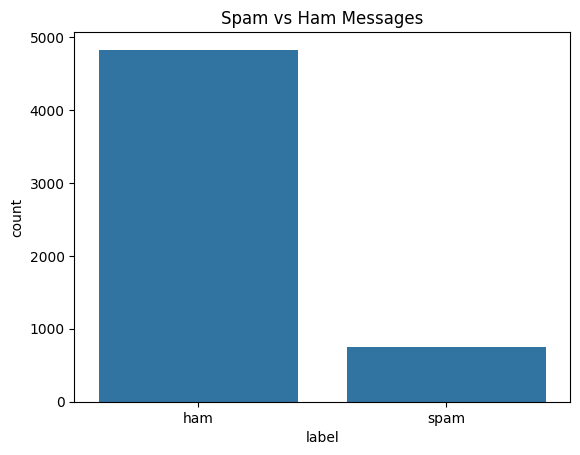

In [9]:
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Messages")

plt.show()

#Message Length Analysis

In [10]:
df['length'] = df['message'].apply(len)

df.head()

,label,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


Plot Distribution

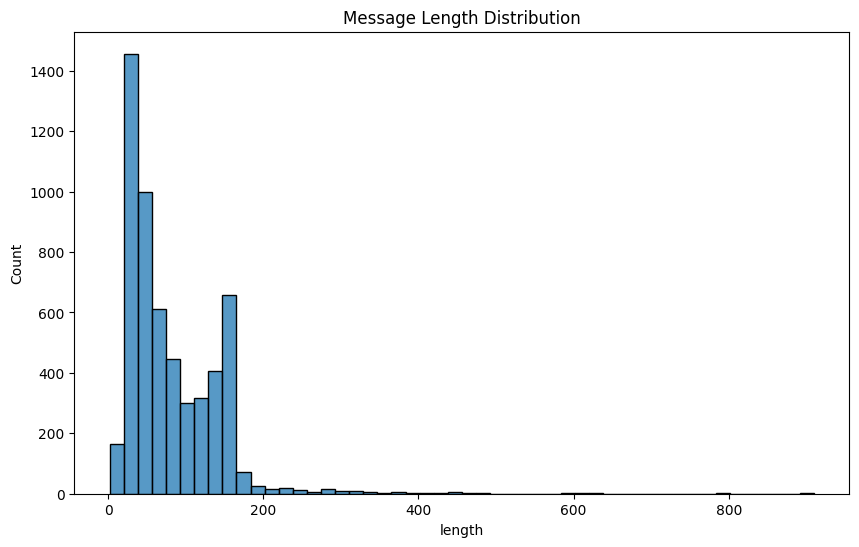

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(df['length'], bins=50)

plt.title("Message Length Distribution")

plt.show()

#WordCloud Visualization

Spam Messages

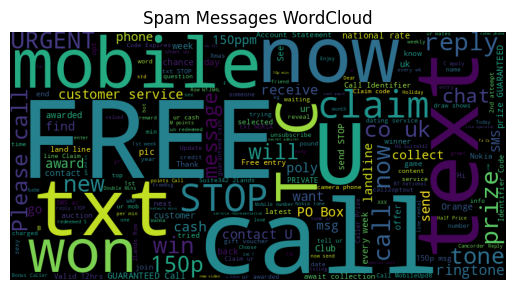

In [12]:
spam_words = ' '.join(list(df[df['label']=='spam']['message']))

wordcloud = WordCloud(width=800,height=400).generate(spam_words)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Messages WordCloud")

plt.show()

Ham Messages

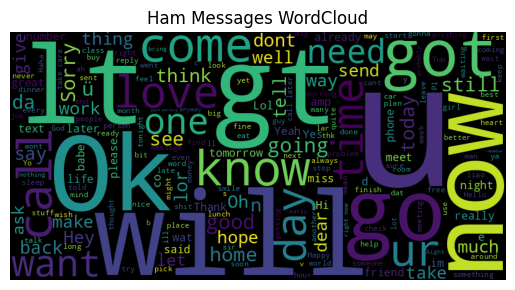

In [13]:
ham_words = ' '.join(list(df[df['label']=='ham']['message']))

wordcloud = WordCloud(width=800,height=400).generate(ham_words)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham Messages WordCloud")

plt.show()

#Text Preprocessing

In [18]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [19]:
stop_words = set(stopwords.words('english'))

def preprocess(text):

    text = text.lower()

    words = word_tokenize(text)

    words = [word for word in words if word.isalpha()]

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [20]:
df['clean_message'] = df['message'].apply(preprocess)

df.head()

,label,message,length,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry wkly comp win fa cup final tkts may...
3,ham,U dun say so early hor... U c already then say...,49,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah think goes usf lives around though


#Feature Extraction using TF-IDF

In [21]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_message'])

y = df['label']

In [22]:
y = y.map({'ham':0,'spam':1})

#Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(

    X, y,

    test_size=0.2,

    random_state=42
)

#Train Model - Naive Bayes

In [24]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

#Evaluate Naive Bayes

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

print(classification_report(y_test, y_pred_nb))

Accuracy: 0.9730941704035875
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



Confusion Matrix

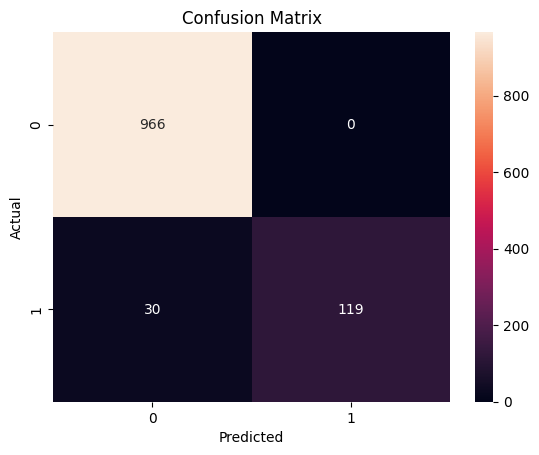

In [26]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

#Train Logistic Regression Model

In [27]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

#Evaluate Logistic Regression

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9596412556053812
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.97      0.72      0.83       149

    accuracy                           0.96      1115
   macro avg       0.97      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



#Model Comparison

In [29]:
results = {

'Naive Bayes': accuracy_score(y_test, y_pred_nb),

'Logistic Regression': accuracy_score(y_test, y_pred_lr)

}

results

{'Naive Bayes': 0.9730941704035875, 'Logistic Regression': 0.9596412556053812}

Plot Comparison

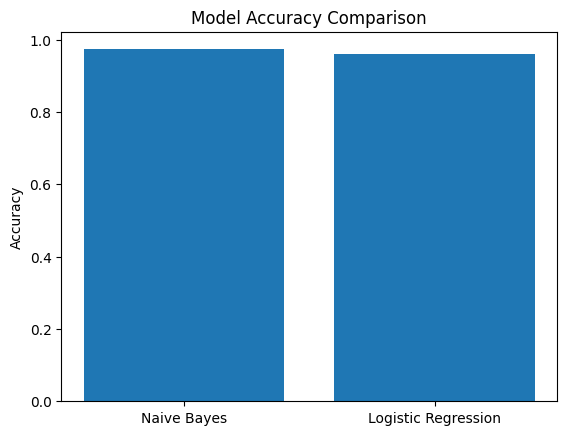

In [30]:
plt.bar(results.keys(), results.values())

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

#Test with Custom Message

In [31]:
sample = ["Congratulations! You won a free lottery"]

sample = vectorizer.transform(sample)

prediction = nb_model.predict(sample)

if prediction[0] == 1:

    print("Spam Message")

else:

    print("Ham Message")

Spam Message


#Conclusion

In this project, a machine learning model was developed to classify SMS messages as spam or ham. The dataset was preprocessed using text cleaning techniques such as lowercasing, tokenization, and stopword removal.

TF-IDF vectorization was used to convert textual data into numerical features. Two classification algorithms, Naive Bayes and Logistic Regression, were trained and evaluated.

The results show that machine learning models can effectively detect spam messages with high accuracy, demonstrating the usefulness of NLP techniques in real-world spam filtering systems.